# 1.5 最简单的【选股＋择时＋回测】全流程

本节用一条小策略走完研究闭环：**选股**决定“考虑买谁”，**择时**决定“什么时候持有”，**回测**用过去的数据模拟交易并核算收益和风险。

固定从沪深 300 成分股中，每 **7 个交易日**挑 **10 只**估值较低的股票；收盘价上穿 **MA20** 才买，下穿或出池就卖；下一交易日开盘模拟成交。检验区间是 **2026-01-05 至 2026-09-30**，比较对象是沪深 300 价格指数。一个交易日指交易所开市的日子，不等于自然日。

## 模块 0｜准备运行环境

下面只导入工具和设置中文图表。核心规则集中在 [`tools/simple_framework_core.py`](tools/simple_framework_core.py)，可以随时打开核对；这页按研究顺序调用它们。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Image as NotebookImage
from tools.simple_framework_core import (
    load_snapshot, load_market_context, clean_inputs, latest_public_report,
    select_pool, build_decisions, run_backtest, performance_metrics,
)
from tools.make_trade_animation import make_trade_animation

font_path = Path('video/assets/NotoSansCJKsc-Regular.otf')
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(font_path)).get_name()
plt.rcParams['axes.unicode_minus'] = False

## 模块 1｜读取并清洗数据：先确认“当时能知道什么”

日线、PE、停牌/ST、沪深 300 成分股和指数来自 BaoStock；财报来自东方财富。`clean_inputs` 校验价格、日期、数值和重复记录，并预先计算每只股票的 MA20。财报的**报告期**不等于**公告日**：例如 2025 年年报在 2026 年才公告，公告前的决策不能使用它。这里更保守地等到公告和更新日期都过去，才把它视为可用。

In [2]:
raw_bars, raw_reports, raw_members, raw_benchmark, manifest = load_snapshot()
bars, reports, members, benchmark, audit = clean_inputs(
    raw_bars, raw_reports, raw_members, raw_benchmark
)
print(f"行情截止 {manifest['latest_bar_date']}；固定沪深300样本 {len(members)} 只")
print(f"原始记录：日线 {len(raw_bars):,} 行，财报 {len(raw_reports):,} 行")
print(f"清洗检查：异常价格 {audit['bad_price_rows']} 行，异常财报 {audit['bad_report_rows']} 行")

行情截止 2026-09-30；固定沪深300样本 300 只
原始记录：日线 61,200 行，财报 1,200 行
清洗检查：异常价格 0 行，异常财报 0 行


## 模块 2｜选股：PE 是什么，为什么用它？

**PE（市盈率）≈ 股价 ÷ 每股收益**；也可以理解为“公司市值 ÷ 一年利润”。例如每股 10 元、过去 12 个月每股赚 1 元，PE 约 **10 倍**。本例的 `peTTM` 中，**TTM** 表示最近连续 12 个月，而不是只看上一季度。PE 低代表价格相对利润较低，但也可能是利润不可持续或市场预期差，**不能直接等同于便宜、值得买**。下表 `close` 是**后复权价**，不能拿它除以某一季度 EPS 倒算 `peTTM`。

在固定的沪深 300 名单里，去掉停牌、ST、无成交、没有已公告正 EPS 财报的股票；只保留 `8 < PE < 30`，按 PE 从小到大取前 10 只。每隔 7 个交易日重新执行一次。这里的 8 和 30 是**演示参数**，不是估值定律。

In [3]:
first_day = pd.Timestamp('2026-01-05')
today = bars.loc[bars.date.eq(first_day)]
known = latest_public_report(reports, first_day)
eligible = today.loc[
    today.peTTM.between(8, 30, inclusive='neither')
    & today.tradestatus.eq(1) & today.volume.gt(0) & today.isST.eq(0)
    & today.ma.notna() & today.code.str[-6:].isin(known.code6)
].sort_values(['peTTM', 'code'])
first_pool = eligible.head(10)[['code', 'peTTM', 'close']]
pool = first_pool.code.tolist()
print(f'{first_day.date()}：可用正EPS财报 {len(known)} 家，满足条件 {len(eligible)} 只，入池 {len(pool)} 只')
display(first_pool.reset_index(drop=True))
assert pool == select_pool(today, reports, first_day)[0]

2026-01-05：可用正EPS财报 281 家，满足条件 154 只，入池 10 只


,code,peTTM,close
0,sh.601628,8.015329,64.939224
1,sh.600000,8.058359,150.870374
2,sh.601601,8.280661,72.829577
3,sh.601669,8.427466,7.042141
4,sh.600018,8.768559,88.964354
5,sh.600027,8.835654,8.835300
6,sh.600023,9.126090,9.914241
7,sh.601288,9.181036,16.977973
8,sh.600741,9.204805,896.853404
9,sh.601318,9.340317,226.699755


## 模块 3｜择时：MA20 上穿买、下穿卖

**MA20** 是最近 20 个交易日收盘价的平均值，帮助我们用一条平滑线观察短期趋势。“上穿”要求**昨天收盘价 ≤ 昨天 MA20，今天收盘价 > 今天 MA20**；“下穿”反过来。只有在当前 10 只股票池中上穿，才进入目标持仓；下穿或 7 日调池时被剔除，就退出。**单纯站在 MA20 上方不算新上穿**，因此入池时如果早已在均线上方，还要等待下一次上穿。

先看一条真实上穿记录，再生成每日决策表。表中 `signal_date` 是看到收盘价的日期，`execution_date` 是下一交易日，避免用当天收盘信息倒回当天开盘成交。

In [4]:
example_cross = bars.loc[
    bars.date.ge(first_day) & bars.code.isin(pool) & bars.cross_up,
    ['date', 'code', 'prev_close', 'prev_ma', 'close', 'ma']
].head(1)
display(example_cross.reset_index(drop=True))
decisions = build_decisions(bars, reports, benchmark, first='2026-01-05', every=7)
display(decisions.loc[decisions.rebalance,
                      ['signal_date', 'execution_date', 'pool_count', 'active_count']].head(5))
print(f"共 {int(decisions.rebalance.sum())} 次调池；每次股票池 10 只，实际持仓可少于 10 只")
assert decisions.pool_count.eq(10).all()
assert (decisions.execution_date > decisions.signal_date).all()

,date,code,prev_close,prev_ma,close,ma
0,2026-03-10,sh.600000,125.725311,126.765577,127.12935,126.701757


,signal_date,execution_date,pool_count,active_count
0,2026-01-05,2026-01-06,10,1
7,2026-01-14,2026-01-15,10,2
14,2026-01-23,2026-01-26,10,3
21,2026-02-03,2026-02-04,10,1
28,2026-02-12,2026-02-13,10,3


共 26 次调池；每次股票池 10 只，实际持仓可少于 10 只


## 模块 4｜模拟成交：把信号变成资金曲线

回测从示例本金 **100 万元**出发，目标股票等权；目标持仓变化或 7 日调池时重配。下一交易日开盘先卖后买，停牌或无量则无法成交；假设买、卖**各自**承担 10 bps（0.1%）综合成本。程序逐日记录现金、持仓和资产净值，并保存每一笔模拟交易。后复权价格只适合近似经济收益；本页的“复权单位”不是真实可下单的 A 股股数。

In [5]:
nav, trades = run_backtest(bars, benchmark, decisions, cost_bps=10)
print(f'模拟成交 {len(trades)} 笔；未成交委托 {int(nav.blocked.sum())} 次')
display(trades[['date', 'code', 'side', 'units', 'adjusted_price', 'fee']].head(5))
assert nav.nav.gt(0).all()
assert trades.empty or (trades.date > trades.signal_date).all()

模拟成交 486 笔；未成交委托 0 次


,date,code,side,units,adjusted_price,fee
0,2026-01-06,sh.601628,BUY,15245.023583,64.939224,990.000000
1,2026-01-07,sh.601628,SELL,7631.791692,66.620890,508.436756
2,2026-01-07,sh.601669,BUY,70940.531841,7.149654,507.200286
3,2026-01-13,sh.601628,SELL,2489.221185,66.459450,165.432271
4,2026-01-13,sh.601669,SELL,24189.191219,7.284046,176.195191


## 模块 5｜评估：盈利和跑赢大盘是两回事

**策略总收益**＝期末净值÷期初净值−1；**超额收益**先简单看策略总收益减沪深 300 同期总收益。**最大回撤**回答“期间最深曾亏多少”；夏普比率衡量收益相对自身波动，信息比率衡量超额收益相对超额波动。这些数字只描述这一段历史，不能只看期末盈利。

In [6]:
m = performance_metrics(nav)
display(pd.DataFrame({'指标': ['策略总收益', '沪深300总收益', '超额收益（两者差）',
                              '最大回撤', '夏普比率', '信息比率', '成交笔数', '累计费用/初始本金'],
                      '结果': [f"{m['总收益率']:.2%}", f"{m['基准总收益率']:.2%}",
                             f"{m['总收益率']-m['基准总收益率']:.2%}",
                             f"{m['最大回撤']:.2%}", f"{m['夏普比率']:.2f}",
                             f"{m['信息比率']:.2f}", str(len(trades)),
                             f"{m['累计费用/初始本金']:.2%}"]}).set_index('指标'))
assert m['总收益率'] > 0 and m['总收益率'] > m['基准总收益率']

,结果
指标,
策略总收益,24.72%
沪深300总收益,-6.54%
超额收益（两者差）,31.26%
最大回撤,-12.05%
夏普比率,1.38
信息比率,1.49
成交笔数,486
累计费用/初始本金,10.21%


把三条曲线统一设为期初 1：策略线展示扣除模拟成本后的资产变化；沪深 300 是主要基准；上证综指只提供市场背景，**不用于判定跑赢大盘**。

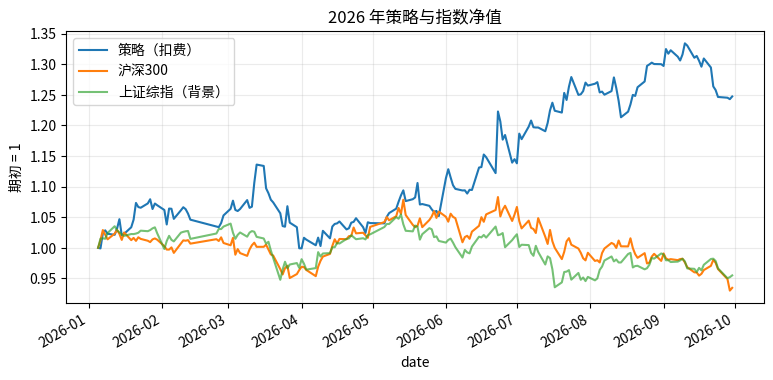

In [7]:
shanghai = load_market_context().set_index('date')['close'].reindex(nav.index)
shanghai = shanghai / shanghai.iloc[0]
ax = nav[['nav', 'benchmark_nav']].rename(columns={
    'nav': '策略（扣费）', 'benchmark_nav': '沪深300'}).plot(figsize=(9, 4))
shanghai.plot(ax=ax, label='上证综指（背景）', alpha=.65)
ax.set(ylabel='期初 = 1', title='2026 年策略与指数净值')
ax.grid(alpha=.25); ax.legend(); plt.show()

## 模块 6｜交易动画：逐阶段检查“究竟买卖了谁”

每帧是一个 7 交易日调池阶段，列出该阶段的模拟买卖股票**名称、方向、复权单位和金额**。它是交易账本的可视化，不是实盘下单记录。

26 个阶段，281 条阶段交易汇总


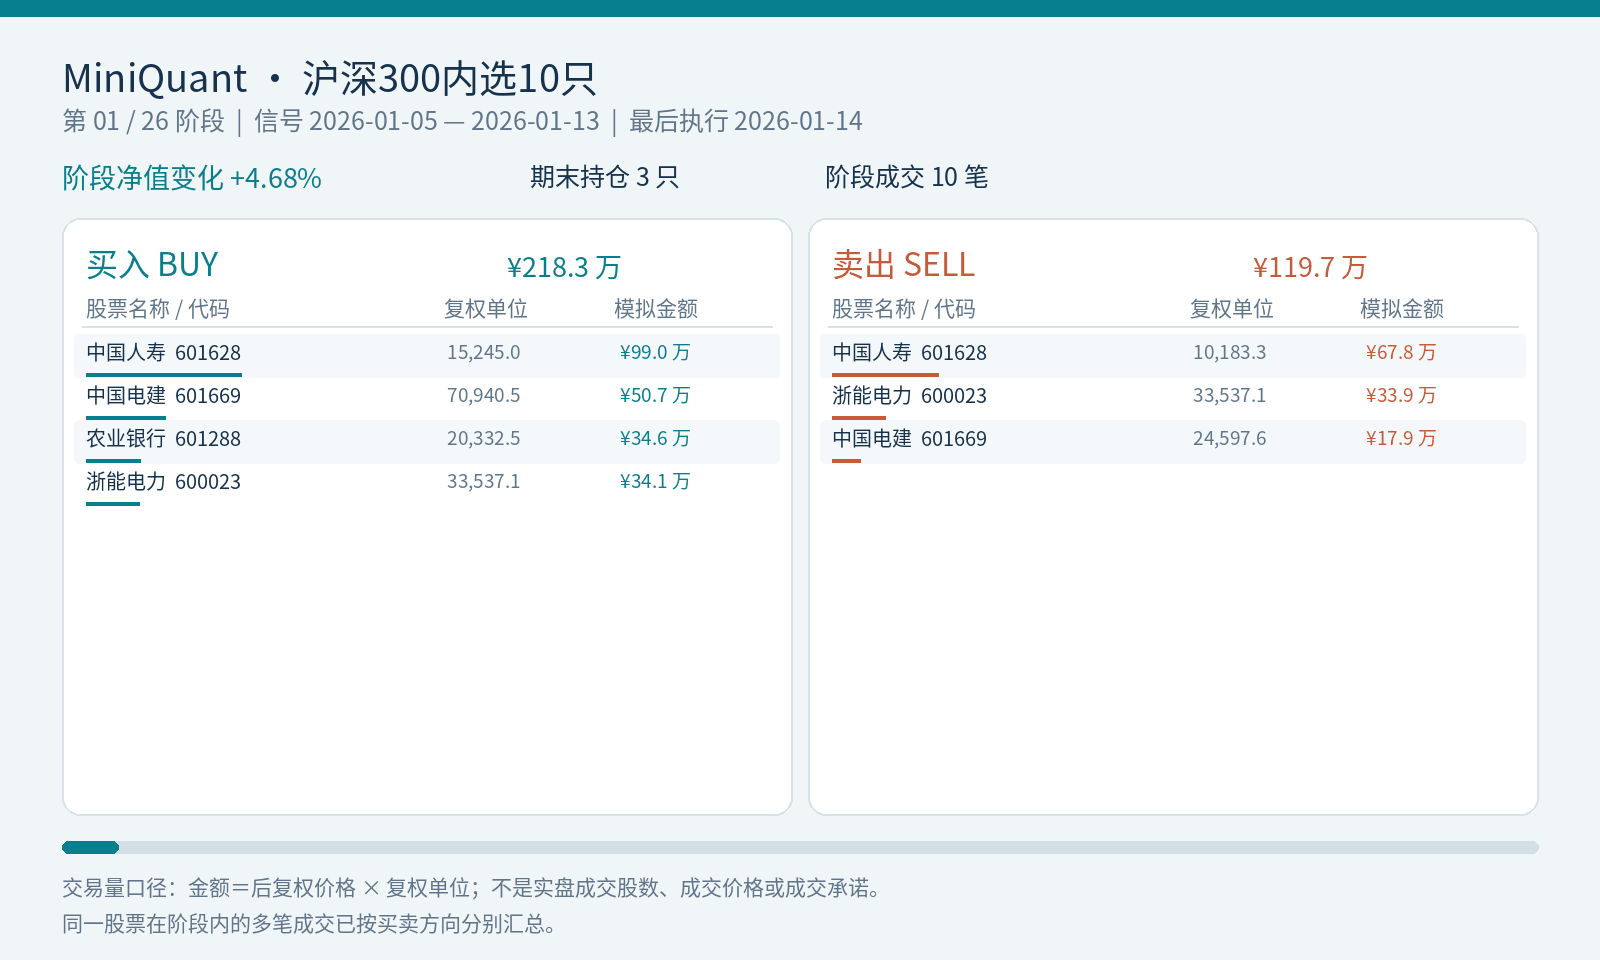

In [8]:
gif_path = Path('figs/simple_framework_trades.gif')
phase_trades = make_trade_animation(trades, decisions, members, nav, gif_path)
print(f'{int(decisions.rebalance.sum())} 个阶段，{len(phase_trades)} 条阶段交易汇总')
display(NotebookImage(filename=str(gif_path), embed=True))

## 看完之后，怎样正确理解这个结果？

本例在 **2026-01-05 至 2026-09-30** 样本内取得正收益并跑赢沪深 300；但参数是在看过这段行情后确定的，**不是独立样本验证，也不能保证以后盈利**。固定初始成分股、后复权成交近似、单边 10 bps 成本、未模拟 A 股整手和涨跌停，都会让实盘结果不同。沪深 300 使用**价格指数**，与股票后复权收益口径不完全一致。下一步应换一段未参与调参的数据，再检查更高成本下是否仍成立。

公开仓库不附带受数据许可约束的原始快照。复现时运行 `python tools/build_simple_snapshot.py --end YYYY-MM-DD` 后再顺序运行本页。数据入口：[BaoStock](https://www.baostock.com/) · [东方财富数据中心](https://data.eastmoney.com/bbsj/)；术语、A 股交易规则和更完整的研究方法见 [MiniQuant 主教程](MiniQuant.ipynb)。